In [2]:
!git clone https://github.com/ayeshanafees48/Tools-and-Tech-70189383
%cd Tools-and-Tech-70189383

Cloning into 'Tools-and-Tech-70189383'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 40 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 1.65 MiB | 7.18 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/Tools-and-Tech-70189383/Tools-and-Tech-70189383


In [3]:
!ls

'01_Tools_and_Technique_by_70189383_(AYESHA_NAFIS) (1).ipynb'
'01_tools_and_technique_by_70189383_(ayesha_nafis).py'
'Assignment No 2 by 70189383 (Ayesha Nafis).pdf'
 Balancing_Data.py
 CA1.csv
 Cross_Validation.py
 Encoder.py
 Graph_Visualize.py
 Scalar.py


In [4]:
import warnings
warnings.filterwarnings("ignore")

## **PREPROCESSING**

In [5]:
#Imports
from Encoder import Encoder
from Balancing_Data import Balancing_Data
from Cross_Validation import CrossValidation
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from Scalar import Scaler
import numpy as np
import warnings
# Load Dataset
df = pd.read_csv("CA1.csv")
print("---------------------------------------------")
print("Original Dataset Shape:", df.shape)
print("---------------------------------------------")

---------------------------------------------
Original Dataset Shape: (12330, 18)
---------------------------------------------


# **Check Frequency of the data weather it is Balance or not**

Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


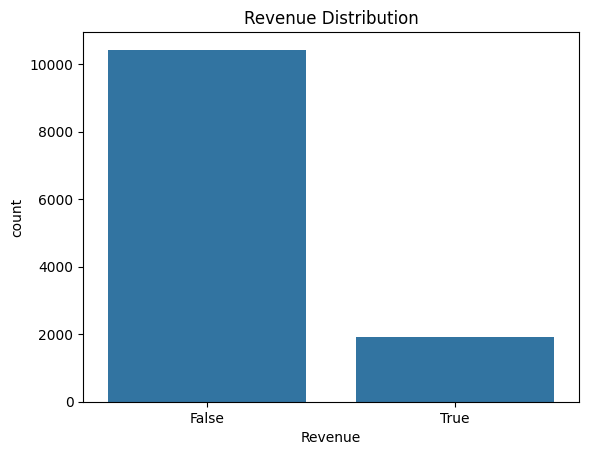

In [6]:
print(df['Revenue'].value_counts())
print(df['Revenue'].value_counts(normalize=True) * 100)
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df['Revenue'])
plt.title("Revenue Distribution")
plt.show()

# **Dataset is imbalance so I apply SMOTE to the dataset to make sure the results are not biased.**

# **DATA CLEANING**

# **Checking Missing Values**

In [7]:
# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())
# Percentage of missing values
print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values in Each Column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Missing Values Percentage:
Administrative             0.0
Administrative_Duration    0.0
Informational              0.0
Informational_Duration     0.0
ProductRelated             0.0
ProductRelated_Duration    0.0
BounceRates                0.0
ExitRates                  0.0
PageValues                 0.0
SpecialDay                 0.0
Month                      0.0
OperatingSystems           0.0
Browser                    0.0
Reg

# **Checking Duplicates**

In [8]:
duplicate_Count = df.duplicated().sum()
print("Duplicate Count (before):", duplicate_Count)
if duplicate_Count > 0:
    duplicate_Rows = df[df.duplicated(keep=False)]
    print("\nDuplicate Rows are:")
    print(duplicate_Rows)
    df = df.drop_duplicates()
    new_count = df.duplicated().sum()
    print("\nDuplicates removed successfully!")
    print("Duplicate Count (after):", new_count)
    print("New shape of dataset:", df.shape)
else:
    print("\nThere is no duplicate in dataset (even after cleaning)")

Duplicate Count (before): 125

Duplicate Rows are:
       Administrative  Administrative_Duration  Informational  \
85                  0                      0.0              0   
132                 0                      0.0              0   
158                 0                      0.0              0   
159                 0                      0.0              0   
178                 0                      0.0              0   
...               ...                      ...            ...   
11934               0                      0.0              0   
11938               0                      0.0              0   
12159               0                      0.0              0   
12180               0                      0.0              0   
12185               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
85                        0.0               1                      0.0   
132                 

# **Checking Typo and Spelling Errors**

In [9]:
valid_months = ['jan','feb','mar','apr','may','june','jul','aug','sep','oct','nov','dec']
df['Month'] = df['Month'].str.lower().str.strip()
invalid_months = df[~df['Month'].isin(valid_months)]['Month'].unique()
print("Invalid Month Values:", invalid_months)
valid_types = ['returning_visitor', 'new_visitor', 'other']
df['VisitorType'] = df['VisitorType'].str.lower().str.strip()
invalid_types = df[~df['VisitorType'].isin(valid_types)]['VisitorType'].unique()
print("Invalid VisitorType Values:", invalid_types)

Invalid Month Values: []
Invalid VisitorType Values: []


# **Handling Outliers**

Administrative Outliers: 404
Administrative_Duration Outliers: 1149
Informational Outliers: 2631
Informational_Duration Outliers: 2405
ProductRelated Outliers: 1007
ProductRelated_Duration Outliers: 951
BounceRates Outliers: 1428
ExitRates Outliers: 1325
PageValues Outliers: 2730
SpecialDay Outliers: 1249

Outlier Type Detection
Administrative --> Skewness: 1.95 --> Right Skewed (Positive Skew)


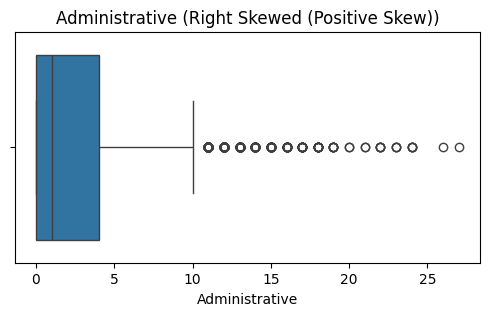

Administrative_Duration --> Skewness: 5.59 --> Right Skewed (Positive Skew)


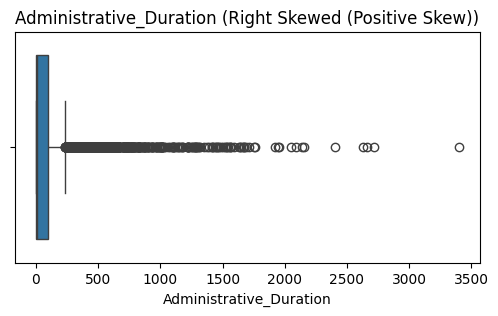

Informational --> Skewness: 4.01 --> Right Skewed (Positive Skew)


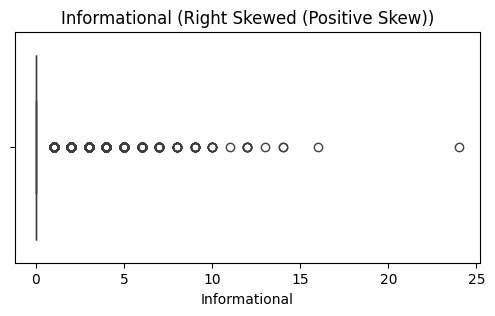

Informational_Duration --> Skewness: 7.54 --> Right Skewed (Positive Skew)


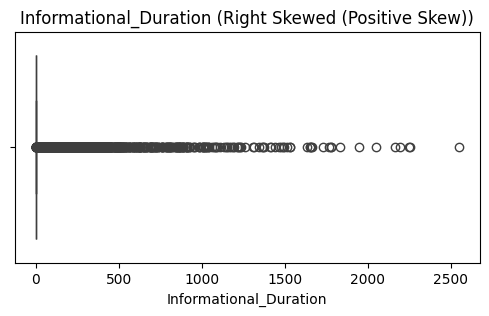

ProductRelated --> Skewness: 4.33 --> Right Skewed (Positive Skew)


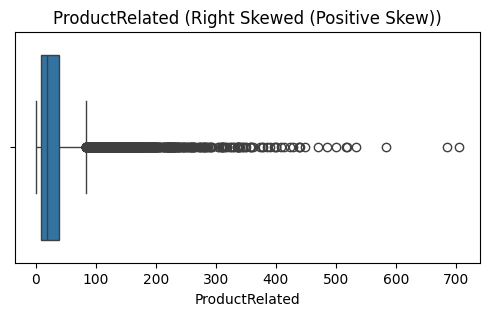

ProductRelated_Duration --> Skewness: 7.25 --> Right Skewed (Positive Skew)


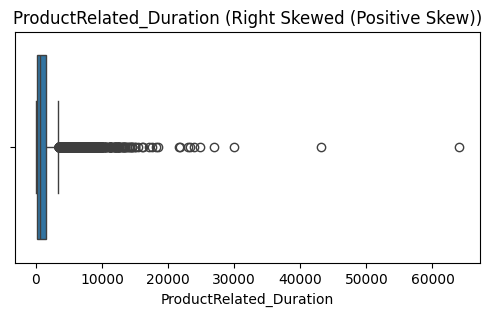

BounceRates --> Skewness: 3.16 --> Right Skewed (Positive Skew)


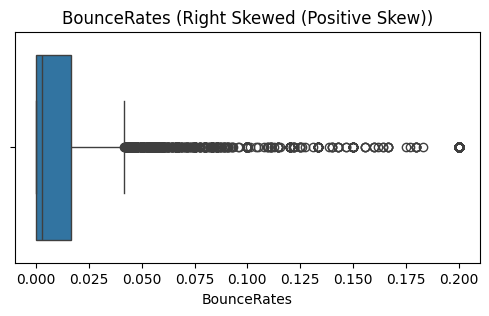

ExitRates --> Skewness: 2.23 --> Right Skewed (Positive Skew)


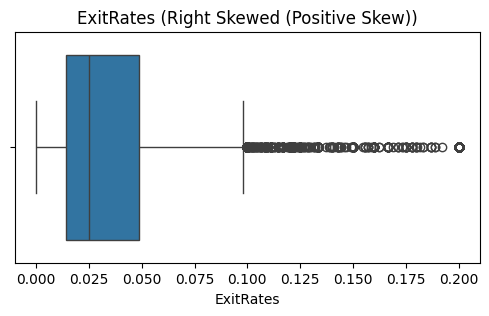

PageValues --> Skewness: 6.35 --> Right Skewed (Positive Skew)


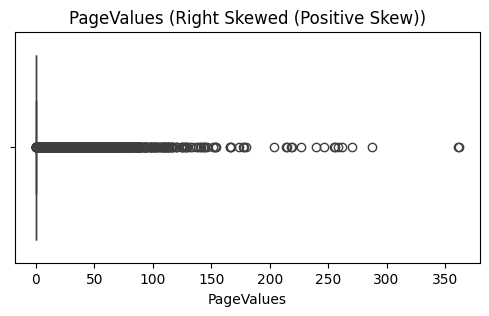

SpecialDay --> Skewness: 3.29 --> Right Skewed (Positive Skew)


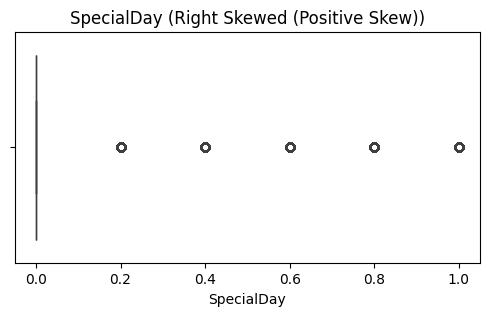

In [10]:
import numpy as np
numerical_cols = [
"Administrative",
"Administrative_Duration",
"Informational",
"Informational_Duration",
"ProductRelated",
"ProductRelated_Duration",
"BounceRates",
"ExitRates",
"PageValues",
"SpecialDay"
]
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(col, "Outliers:", len(outliers))
import matplotlib.pyplot as plt
import seaborn as sns
print("\nOutlier Type Detection")
for col in numerical_cols:
    skew_val = df[col].skew()
    if skew_val > 0.5:
        skew_type = "Right Skewed (Positive Skew)"
    elif skew_val < -0.5:
        skew_type = "Left Skewed (Negative Skew)"
    else:
        skew_type = "Approximately Symmetric"
    print(f"{col} --> Skewness: {skew_val:.2f} --> {skew_type}")
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} ({skew_type})")
    plt.show()

**As the outliers are Right Skewed so there is a need to apply Log Transformation**

In [11]:
transform_Columns = ["Administrative" , "Informational_Duration" , "Informational" , "ProductRelated" , "ProductRelated_Duration" , "BounceRates" , "ExitRates" , "PageValues" , "SpecialDay"]
for transformation in transform_Columns:
  df[transformation] = np.log1p(df[transformation])
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(col, "Outliers After Log Transformation:", len(outliers))

Administrative Outliers After Log Transformation: 0
Administrative_Duration Outliers After Log Transformation: 1149
Informational Outliers After Log Transformation: 2631
Informational_Duration Outliers After Log Transformation: 2405
ProductRelated Outliers After Log Transformation: 30
ProductRelated_Duration Outliers After Log Transformation: 702
BounceRates Outliers After Log Transformation: 1420
ExitRates Outliers After Log Transformation: 980
PageValues Outliers After Log Transformation: 2730
SpecialDay Outliers After Log Transformation: 1249


# **Apply Capping to reach to the zero**

In [12]:
numeric_Columns = ["Administrative_Duration", "Informational" , "Informational_Duration" , "ProductRelated" , "ProductRelated_Duration" , "BounceRates" , "ExitRates" , "PageValues" , "SpecialDay"]
for int_column in numeric_Columns:
  qunatile_1 = df[int_column].quantile(0.25)
  quantile_3 = df[int_column].quantile(0.75)
  calculated_IQR = quantile_3 - qunatile_1
  lower_Bound = qunatile_1 - (1.5 * calculated_IQR)
  upper_Bound = quantile_3 + (1.5 * calculated_IQR)
  df[int_column] = np.where(df[int_column] < lower_Bound , lower_Bound , df[int_column])
  df[int_column] = np.where(df[int_column] > upper_Bound , upper_Bound , df[int_column])
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(col, "Outliers After Capping:", len(outliers))


Administrative Outliers After Capping: 0
Administrative_Duration Outliers After Capping: 0
Informational Outliers After Capping: 0
Informational_Duration Outliers After Capping: 0
ProductRelated Outliers After Capping: 0
ProductRelated_Duration Outliers After Capping: 0
BounceRates Outliers After Capping: 0
ExitRates Outliers After Capping: 0
PageValues Outliers After Capping: 0
SpecialDay Outliers After Capping: 0


# **FEATURE ENGINNERING & DATA TRANSFORMATION**

In [13]:
# 1. Total Time Spent
df['Total_Time'] = ( df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration'] )
# 2. Total Pages Visited
df['Total_Pages'] = ( df['Administrative'] + df['Informational'] + df['ProductRelated'] )
# 3. Engagement Ratio
df['Engagement_Ratio'] = df['Total_Time'] / (df['Total_Pages'] + 1)
# 4. Value Per Page
df['Value_Per_Page'] = df['PageValues'] / (df['ProductRelated'] + 1)
print("\nNew Features Added Successfully")
print(df[['Total_Time', 'Total_Pages', 'Engagement_Ratio', 'Value_Per_Page']].head())
df.info()


New Features Added Successfully
   Total_Time  Total_Pages  Engagement_Ratio  Value_Per_Page
0    2.221821     0.693147          1.312243             0.0
1    4.174387     1.098612          1.989118             0.0
2    2.221821     0.693147          1.312243             0.0
3    2.221821     1.098612          1.058709             0.0
4    6.443336     2.397895          1.896273             0.0
<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  float64
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  float64
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  float64
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRa

# **ADVANCE FEATURE ENGINNERING & INTERACTION**


*   Polynomial Features




In [14]:
from sklearn.preprocessing import PolynomialFeatures
poly_cols = [
    'Total_Time',
    'Total_Pages',
    'Engagement_Ratio',
    'Value_Per_Page'
]
# Polynomial Feature Object
poly = PolynomialFeatures(degree=2, include_bias=False)
# Create Features
poly_features = poly.fit_transform(df[poly_cols])
# Feature Names
poly_feature_names = poly.get_feature_names_out(poly_cols)
# Convert to DataFrame
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)
# Remove original duplicate columns
poly_df = poly_df.drop(columns=poly_cols)
# Merge with original dataset
df = pd.concat([df.reset_index(drop=True), poly_df.reset_index(drop=True)], axis=1)
print("\nPolynomial Features Added Successfully")
df.info()


Polynomial Features Added Successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Administrative                   12205 non-null  float64
 1   Administrative_Duration          12205 non-null  float64
 2   Informational                    12205 non-null  float64
 3   Informational_Duration           12205 non-null  float64
 4   ProductRelated                   12205 non-null  float64
 5   ProductRelated_Duration          12205 non-null  float64
 6   BounceRates                      12205 non-null  float64
 7   ExitRates                        12205 non-null  float64
 8   PageValues                       12205 non-null  float64
 9   SpecialDay                       12205 non-null  float64
 10  Month                            12205 non-null  object 
 11  OperatingSystems                 12205 n

# **BINNING**

In [15]:
print(df['ProductRelated_Duration'].min())
print(df['ProductRelated_Duration'].max())
print(df['PageValues'].min())
print(df['PageValues'].max())

2.2218206879895015
10.344587277519706
0.0
0.0


In [16]:
# ProductRelated_Duration
df['ProductRelated_Duration_Bin'] = pd.cut(
    df['ProductRelated_Duration'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)
# BounceRates
df['BounceRates_Bin'] = pd.cut(
    df['BounceRates'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

print(df[['ProductRelated_Duration_Bin',
          'BounceRates_Bin']].head())

  ProductRelated_Duration_Bin BounceRates_Bin
0                         Low            High
1                         Low             Low
2                         Low            High
3                         Low            High
4                      Medium          Medium


# **Feature Transformation: Scaling and Encoding**

In [17]:
binary_cols = ["Weekend" , "Revenue"]
nominal_cols = ["Month", "VisitorType"]
ordinal_cols = ["Browser" , "Region" , "OperatingSystems" , "TrafficType" , 'ProductRelated_Duration_Bin', 'BounceRates_Bin']
encoder = Encoder()
# Apply encoding on full dataset
X = encoder.label_encode(df, binary_cols)
X = encoder.onehot_encode(X, nominal_cols)
X = encoder.label_encode(X, ordinal_cols)
print("---------------------------------------------")
print("After Encoding Shape:", X.shape)
print("---------------------------------------------")
# -------------------------------
# Scaling
# -------------------------------
numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Total_Time",
    "Total_Pages",
    "Engagement_Ratio",
    "Value_Per_Page"
]
scaler = Scaler(method="standard")
# Fit + Transform on full dataset
X = scaler.fit_transform(X, numerical_cols)
X.describe()
print("---------------------------------------------")
print("After Scaling Shape:", X.shape)
print("---------------------------------------------")
X.head()

---------------------------------------------
After Encoding Shape: (12205, 43)
---------------------------------------------
---------------------------------------------
After Scaling Shape: (12205, 43)
---------------------------------------------


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_feb,Month_jul,Month_june,Month_mar,Month_may,Month_nov,Month_oct,Month_sep,VisitorType_other,VisitorType_returning_visitor
0,-0.932479,-0.721911,0.0,0.0,-2.001350,-2.389594,2.147202,2.222963,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.932479,-0.721911,0.0,0.0,-1.634840,-1.198896,-0.728527,2.153223,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.932479,-0.721911,0.0,0.0,-2.001350,-2.389594,2.147202,2.222963,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.932479,-0.721911,0.0,0.0,-1.634840,-2.389594,2.147202,2.222963,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.932479,-0.721911,0.0,0.0,-0.460384,0.184735,0.649559,0.502485,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Administrative                   12205 non-null  float64
 1   Administrative_Duration          12205 non-null  float64
 2   Informational                    12205 non-null  float64
 3   Informational_Duration           12205 non-null  float64
 4   ProductRelated                   12205 non-null  float64
 5   ProductRelated_Duration          12205 non-null  float64
 6   BounceRates                      12205 non-null  float64
 7   ExitRates                        12205 non-null  float64
 8   PageValues                       12205 non-null  float64
 9   SpecialDay                       12205 non-null  float64
 10  OperatingSystems                 12205 non-null  int64  
 11  Browser                          12205 non-null  int64  
 12  Region            

# **STATISTICAL ANALYSIS**


In [19]:
# -------------------------------
# Statistical Analysis
# -------------------------------
numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]
# Mean
print("Mean:")
print(df[numerical_cols].mean())
# Median
print("\nMedian:")
print(df[numerical_cols].median())
# Mode
print("\nMode:")
print(df[numerical_cols].mode().iloc[0])
# Standard Deviation
print("\nStandard Deviation:")
print(df[numerical_cols].std())
# Variance
print("\nVariance:")
print(df[numerical_cols].var())
# Minimum Values
print("\nMinimum Values:")
print(df[numerical_cols].min())
# Maximum Values
print("\nMaximum Values:")
print(df[numerical_cols].max())
# Complete Statistical Summary
print("\nStatistical Summary:")
print(df[numerical_cols].describe())

Mean:
Administrative              0.805126
Administrative_Duration    57.899459
Informational               0.000000
Informational_Duration      0.000000
ProductRelated              2.907211
ProductRelated_Duration     6.140398
BounceRates                 0.010469
ExitRates                   0.034629
PageValues                  0.000000
SpecialDay                  0.000000
dtype: float64

Median:
Administrative             0.693147
Administrative_Duration    9.000000
Informational              0.000000
Informational_Duration     0.000000
ProductRelated             2.944439
ProductRelated_Duration    6.413365
BounceRates                0.002894
ExitRates                  0.024693
PageValues                 0.000000
SpecialDay                 0.000000
dtype: float64

Mode:
Administrative             0.000000
Administrative_Duration    0.000000
Informational              0.000000
Informational_Duration     0.000000
ProductRelated             0.693147
ProductRelated_Duration    2.221821
Bo

# **HEAT MAP**


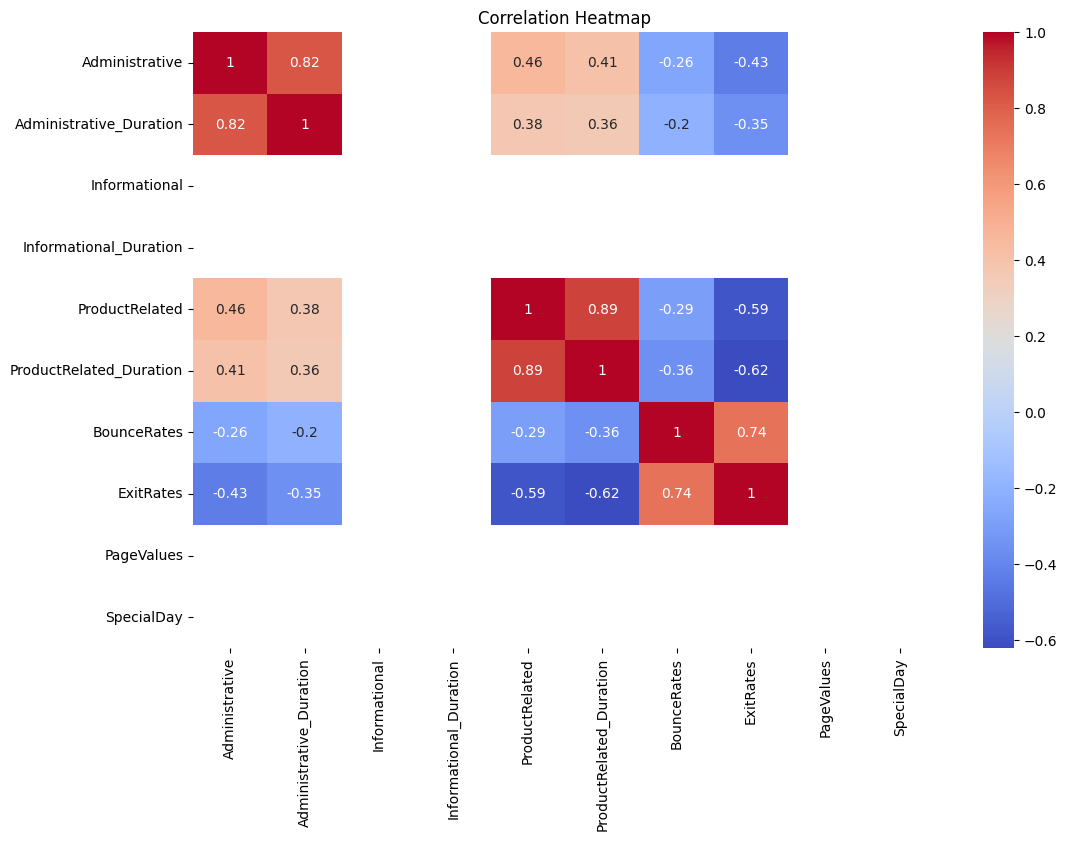

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

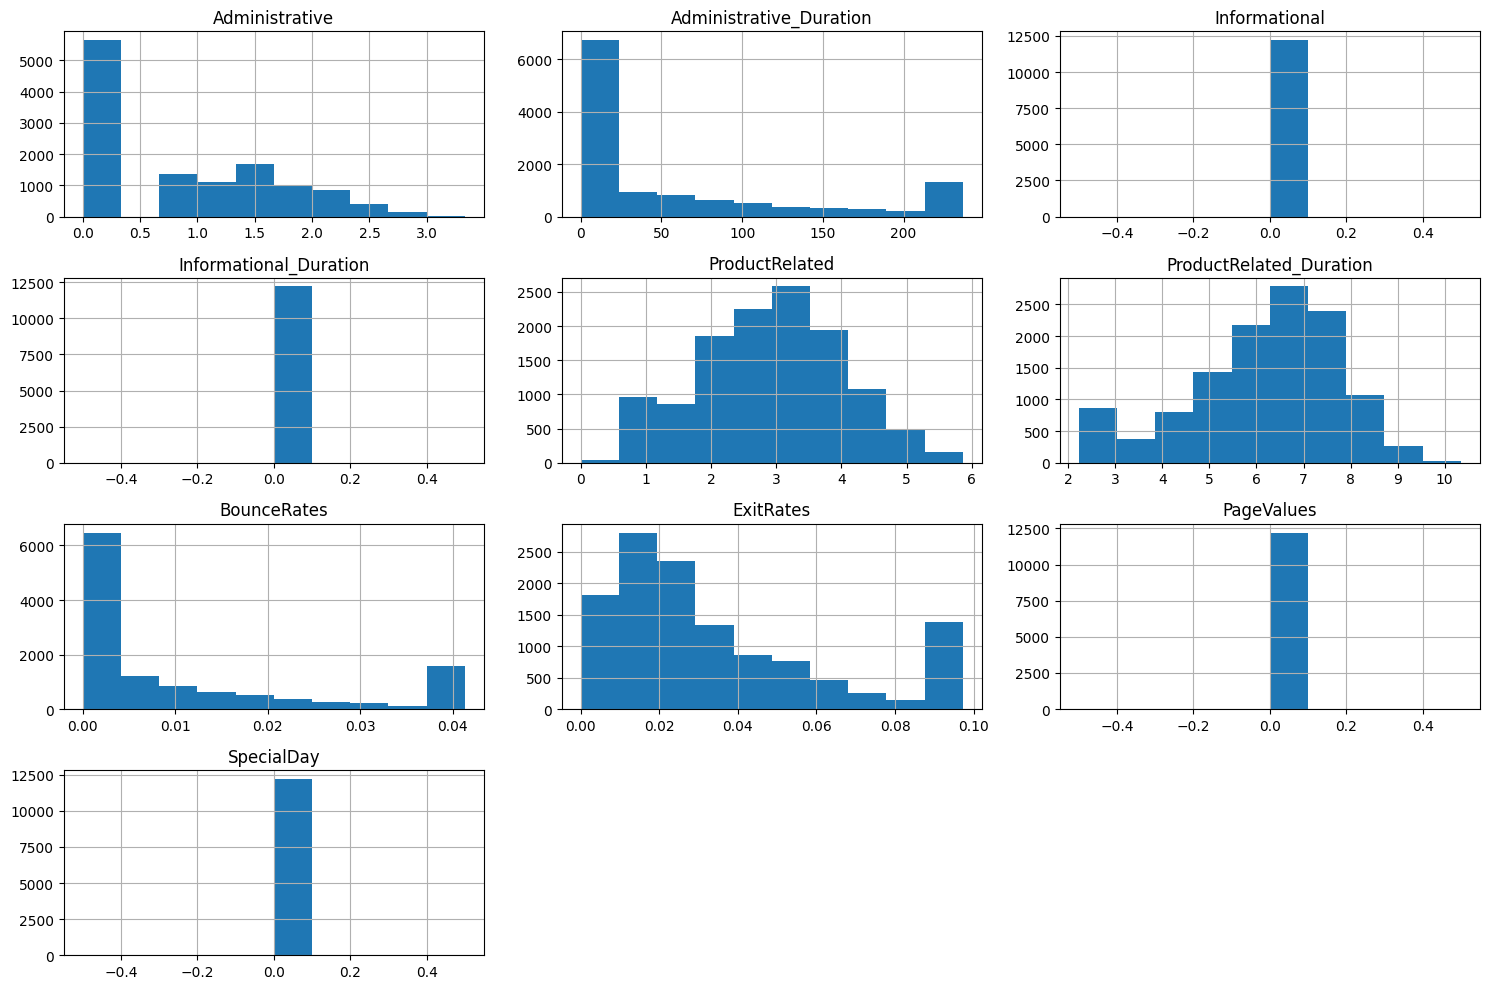

In [21]:
df[numerical_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

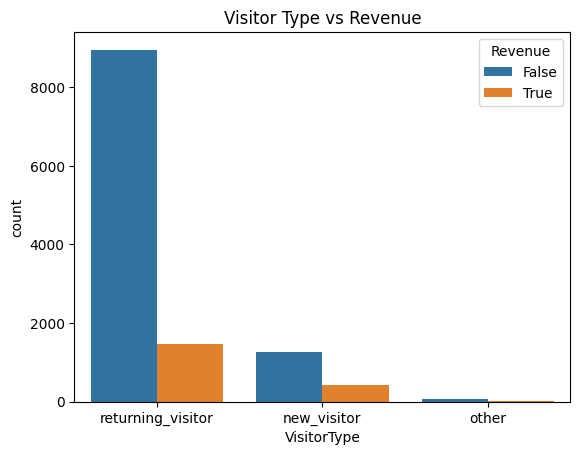

In [22]:
sns.countplot(x='VisitorType',hue='Revenue',data=df)
plt.title("Visitor Type vs Revenue")
plt.show()

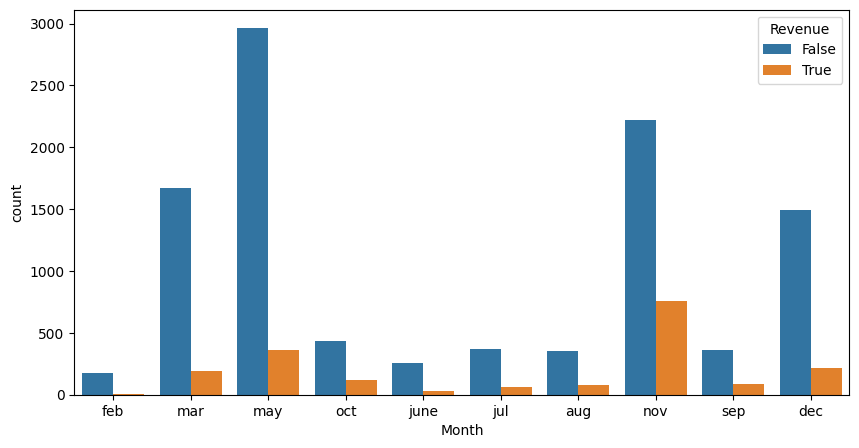

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(x='Month',hue='Revenue',data=df)
plt.show()

# **FEATURE SELECION, VARIAN THRESHOLD, CORELATION FILTER, UNIVARIATE FEATURE SELECTION, SMOTE, MODEELLING, & EVALUATIONS**

In [24]:
# FEATURE SELECTION
# Target
y = X['Revenue']
X = X.drop(columns=['Revenue'])
print("Original Shape :", X.shape)
# VARIANCE THRESHOLD
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X)
selected_cols = X.columns[vt.get_support()]
X = pd.DataFrame(X_vt, columns=selected_cols)
print("After Variance Threshold :", X.shape)
# CORRELATION FILTER
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [col
    for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.90)
]
X = X.drop(columns=drop_cols)
print("After Correlation Filter :", X.shape)
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )
print("Train :", X_train.shape)
print("Test  :", X_test.shape)
# UNIVARIATE FEATURE SELECTION
kbest = SelectKBest( score_func=mutual_info_classif, k=min(20, X_train.shape[1]))
X_train_uni = kbest.fit_transform(X_train, y_train)
X_test_uni = kbest.transform(X_test)
selected_uni = X_train.columns[kbest.get_support()]
X_train_uni = pd.DataFrame( X_train_uni, columns=selected_uni )
X_test_uni = pd.DataFrame( X_test_uni, columns=selected_uni )
print("After Univariate :", X_train_uni.shape)
# RFE
base_model = LogisticRegression(max_iter=5000)
n_features = min(10, X_train_uni.shape[1])
rfe = RFE( estimator=base_model, n_features_to_select=n_features)
X_train_rfe = rfe.fit_transform(X_train_uni, y_train )
X_test_rfe = rfe.transform(X_test_uni)
final_features = X_train_uni.columns[rfe.support_]
X_train_rfe = pd.DataFrame( X_train_rfe, columns=final_features )
X_test_rfe = pd.DataFrame( X_test_rfe, columns=final_features )
print("Final Features")
print(final_features.tolist())
print("Train Shape :", X_train_rfe.shape)
print("Test Shape  :", X_test_rfe.shape)
# SMOTE
balancer = Balancing_Data( X_train_rfe, y_train )
X_smote_rs, y_smote_rs = balancer.SMOTE_with_RandomState(42)
print("SMOTE Shape :", X_smote_rs.shape)
# MODEL EVALUATION
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Gaussian NB": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier( random_state=42 ),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}
results = []
for name, model in models.items():
    model.fit( X_smote_rs, y_smote_rs )
    y_pred = model.predict( X_test_rfe )
    acc = accuracy_score( y_test,y_pred)
    prec = precision_score( y_test, y_pred,zero_division=0)
    rec = recall_score(y_test,y_pred,zero_division=0)
    f1 = f1_score(y_test,y_pred,zero_division=0)
    print(name)
    print( "Accuracy :",round(acc,4))
    print( "Precision:",round(prec,4))
    print( "Recall   :",round(rec,4))
    print( "F1 Score :",round(f1,4))
    print( "Confusion Matrix\n",confusion_matrix(y_test,y_pred))
    results.append(
        [
            name,
            acc,
            prec,
            rec,
            f1
        ]
    )
# FINAL COMPARISON
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)
# Recall primary, Accuracy secondary
results_df = results_df.sort_values(
    by=["Recall", "Accuracy"],
    ascending=[False, False]
)
print("\n")
print("BEST MODEL")
print(results_df)
best_model = results_df.iloc[0]["Model"]
best_recall = results_df.iloc[0]["Recall"]
best_accuracy = results_df.iloc[0]["Accuracy"]
print("FINAL SELECTED MODEL")
print("Model    :", best_model)
print("Recall   :", round(best_recall,4))
print("Accuracy :", round(best_accuracy,4))
print("Reason   : Highest Recall with Highest Accuracy")

Original Shape : (12205, 42)
After Variance Threshold : (12205, 32)
After Correlation Filter : (12205, 24)
Train : (9764, 24)
Test  : (2441, 24)
After Univariate : (9764, 20)
Final Features
['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'BounceRates_Bin', 'Month_dec', 'Month_mar', 'Month_may', 'Month_nov', 'VisitorType_returning_visitor']
Train Shape : (9764, 10)
Test Shape  : (2441, 10)
SMOTE Shape : (16476, 10)
Logistic Regression
Accuracy : 0.6387
Precision: 0.2668
Recall   : 0.7487
F1 Score : 0.3934
Confusion Matrix
 [[1273  786]
 [  96  286]]
Gaussian NB
Accuracy : 0.5248
Precision: 0.2268
Recall   : 0.8455
F1 Score : 0.3577
Confusion Matrix
 [[ 958 1101]
 [  59  323]]
Decision Tree
Accuracy : 0.7075
Precision: 0.2398
Recall   : 0.4005
F1 Score : 0.3
Confusion Matrix
 [[1574  485]
 [ 229  153]]
Random Forest
Accuracy : 0.7513
Precision: 0.2807
Recall   : 0.377
F1 Score : 0.3218
Confusion Matrix
 [[1690  369]
 [ 238  144]]


BEST MODEL
                 Mo

# **WITH CROSS VALIDATION**

In [25]:
# CROSS VALIDATION
from sklearn.model_selection import cross_val_score
cv_results = {}
print("CROSS VALIDATION RESULTS")
cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Gaussian NB": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}
for name, model in cv_models.items():
    cv_scores = cross_val_score(
        model,
        X_smote_rs,
        y_smote_rs,
        cv=5,
        scoring='recall'
    )
    cv_results[name] = round(cv_scores.mean(), 4)
    print(f"\n{name}")
    print("CV Scores :", cv_scores)
    print("Mean Recall :", round(cv_scores.mean(), 4))
    print("Std Dev :", round(cv_scores.std(), 4))
# FINAL COMPARISON
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)
results_df["CV_Recall"] = results_df["Model"].map(cv_results)
results_df = results_df.sort_values(
    by=["Recall", "Accuracy", "CV_Recall"],
    ascending=[False, False, False]
)
print("\n================================")
print("MODEL COMPARISON")
print("================================")
print(results_df)
best_model = results_df.iloc[0]["Model"]
print("\n================================")
print("FINAL SELECTED MODEL")
print("================================")
print("Model      :", best_model)
print("Accuracy   :", round(results_df.iloc[0]["Accuracy"], 4))
print("Recall     :", round(results_df.iloc[0]["Recall"], 4))
print("CV Recall  :", round(results_df.iloc[0]["CV_Recall"], 4))
print("\nReason:")
print("Selected based on Highest Recall, Highest Accuracy and Highest Cross Validation Recall.")

CROSS VALIDATION RESULTS

Logistic Regression
CV Scores : [0.74453883 0.74635922 0.7342233  0.75591985 0.7431694 ]
Mean Recall : 0.7448
Std Dev : 0.0069

Gaussian NB
CV Scores : [0.85254854 0.85679612 0.8586165  0.86581664 0.86945962]
Mean Recall : 0.8606
Std Dev : 0.0061

Decision Tree
CV Scores : [0.72512136 0.83313107 0.83677184 0.82270795 0.83120826]
Mean Recall : 0.8098
Std Dev : 0.0426

Random Forest
CV Scores : [0.8288835  0.91929612 0.9375     0.91863995 0.9247116 ]
Mean Recall : 0.9058
Std Dev : 0.0391

MODEL COMPARISON
                 Model  Accuracy  Precision    Recall        F1  CV_Recall
1          Gaussian NB  0.524785   0.226826  0.845550  0.357697     0.8606
0  Logistic Regression  0.638673   0.266791  0.748691  0.393398     0.7448
2        Decision Tree  0.707497   0.239812  0.400524  0.300000     0.8098
3        Random Forest  0.751331   0.280702  0.376963  0.321788     0.9058

FINAL SELECTED MODEL
Model      : Gaussian NB
Accuracy   : 0.5248
Recall     : 0.8455
CV 

# **Final Comparision**

In [26]:
# BEST MODEL WITHOUT CV
best_without_cv = results_df.sort_values( by=["Recall", "Accuracy"], ascending=[False, False] ).iloc[0]
# BEST MODEL WITH CV
best_with_cv = results_df.sort_values(
    by=["Recall", "Accuracy", "CV_Recall"],
    ascending=[False, False, False]
).iloc[0]
print("\n================================")
print("BEST MODEL WITHOUT CV")
print("================================")
print(best_without_cv["Model"])
print("\n================================")
print("BEST MODEL WITH CV")
print("================================")
print(best_with_cv["Model"])
# =====================================================
# FINAL WINNER
# =====================================================
if best_without_cv["Model"] == best_with_cv["Model"]:
    final_model = best_with_cv["Model"]
else:
    if best_with_cv["CV_Recall"] >= best_without_cv["CV_Recall"]:
        final_model = best_with_cv["Model"]
    else:
        final_model = best_without_cv["Model"]
print("\n================================")
print("FINAL BEST MODEL")
print("================================")
print("Model      :", final_model)
final_row = results_df[results_df["Model"] == final_model].iloc[0]
print("Accuracy   :", round(final_row["Accuracy"],4))
print("Recall     :", round(final_row["Recall"],4))
print("CV Recall  :", round(final_row["CV_Recall"],4))
print("\nReason : Selected using Recall, Accuracy and Cross Validation Recall.")


BEST MODEL WITHOUT CV
Gaussian NB

BEST MODEL WITH CV
Gaussian NB

FINAL BEST MODEL
Model      : Gaussian NB
Accuracy   : 0.5248
Recall     : 0.8455
CV Recall  : 0.8606

Reason : Selected using Recall, Accuracy and Cross Validation Recall.


                          Feature     Score
5                       ExitRates  0.040194
3         ProductRelated_Duration  0.032201
10                    Total_Pages  0.026434
2                  ProductRelated  0.021031
12                BounceRates_Bin  0.020140
11    ProductRelated_Duration_Bin  0.018896
4                     BounceRates  0.018793
8                     TrafficType  0.014532
0                  Administrative  0.013870
19  VisitorType_returning_visitor  0.012861
1         Administrative_Duration  0.011078
17                      Month_nov  0.009186
14                      Month_jul  0.006350
18                      Month_sep  0.006350
9                         Weekend  0.005205
16                      Month_may  0.004717
13                      Month_dec  0.002387
15                      Month_mar  0.002376
6                         Browser  0.001985
7                          Region  0.001153


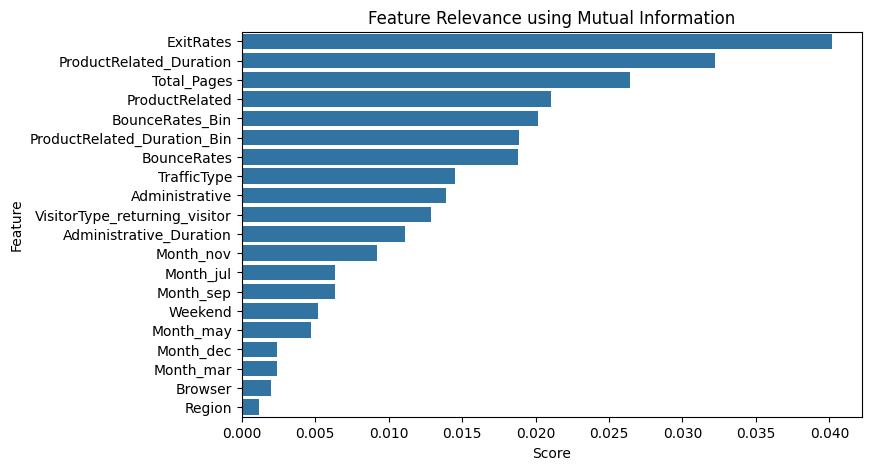

In [27]:
mi_scores = pd.DataFrame({
    "Feature": selected_uni,
    "Score": kbest.scores_[kbest.get_support()]
})
mi_scores = mi_scores.sort_values(
    by="Score",
    ascending=False
)
print(mi_scores)
plt.figure(figsize=(8,5))
sns.barplot(
    data=mi_scores,
    x="Score",
    y="Feature"
)
plt.title("Feature Relevance using Mutual Information")
plt.show()

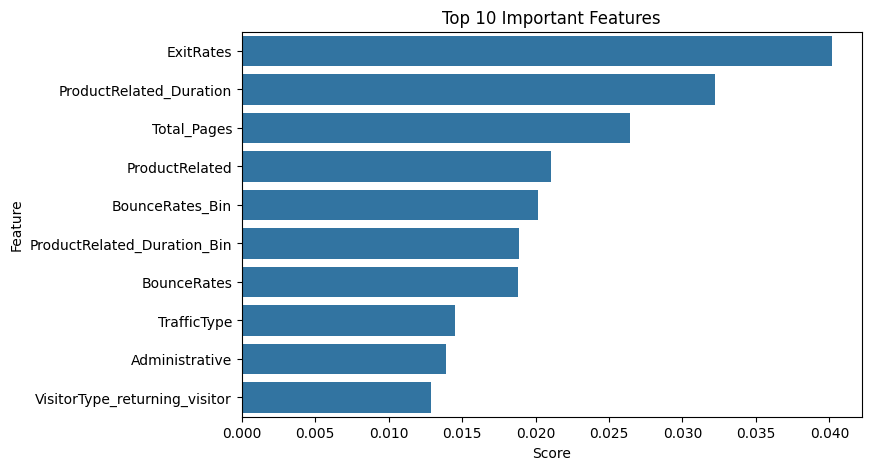

In [28]:
top_features = mi_scores.head(10)
plt.figure(figsize=(8,5))
sns.barplot(
    data=top_features,
    x="Score",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()